# **Classification of Anticancer Peptides (ACPs) Using Sequence-Based Features**

# **Data Loading and Preprocessing**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load datasets
df_lung = pd.read_csv('ACPs_Lung_cancer.csv')
df_breast = pd.read_csv('ACPs_Breast_cancer.csv')

def preprocess_acp_data(df, label):
    df = df.copy()
    # Binary Classification: Active (mod + very) vs Inactive (exp + virtual)
    active_labels = ['mod. active', 'very active']
    df['target'] = df['class'].apply(lambda x: 'Active' if x in active_labels else 'Inactive')
    # Feature Engineering: Sequence Length
    df['length'] = df['sequence'].str.len()
    df['source'] = label
    return df

df_lung_proc = preprocess_acp_data(df_lung, 'Lung Cancer')
df_breast_proc = preprocess_acp_data(df_breast, 'Breast Cancer')
df_all = pd.concat([df_lung_proc, df_breast_proc], ignore_index=True)

## **Dataset Inspection**

In [ ]:
df_all.head()

,ID,sequence,class,target,length,source
0,1,AIGKFLHSAKKFGKAFVGEIMNS,mod. active,Active,23,Lung Cancer
1,2,FAKALAKLAKKLL,mod. active,Active,13,Lung Cancer
2,3,FAKALKALLKALKAL,mod. active,Active,15,Lung Cancer
3,4,FAKFLAKFLKKAL,mod. active,Active,13,Lung Cancer
4,5,FAKIIAKIAKIAKKIL,inactive - exp,Inactive,16,Lung Cancer


# **Exploratory Data analysis**

## **Descriptive Statistical Analysis**

In [ ]:
df_all.describe()

,ID,length
count,1850.000000,1850.000000
mean,463.311351,16.728649
std,267.635239,4.881604
min,1.000000,5.000000
25%,232.000000,13.000000
50%,463.000000,16.000000
75%,694.000000,20.000000
max,949.000000,38.000000


## **Check for Missing Values**

In [ ]:
def basic_quality_check(df, name):
    print(f"--- Quality Check: {name} ---")
    # Check for actual null values
    print(f"Missing values:\n{df.isnull().sum()}\n")

    # Check for empty strings in sequence
    empty_seqs = df[df['sequence'].str.strip() == ""].shape[0]
    print(f"Empty sequence strings: {empty_seqs}")

    # Check for duplicate sequences
    duplicates = df.duplicated(subset=['sequence']).sum()
    print(f"Duplicate sequences: {duplicates}")
    print("-" * 30)

basic_quality_check(df_lung, "Lung Cancer Dataset")
basic_quality_check(df_breast, "Breast Cancer Dataset")

--- Quality Check: Lung Cancer Dataset ---
Missing values:
ID          0
sequence    0
class       0
dtype: int64

Empty sequence strings: 0
Duplicate sequences: 0
------------------------------
--- Quality Check: Breast Cancer Dataset ---
Missing values:
ID          0
sequence    0
class       0
dtype: int64

Empty sequence strings: 0
Duplicate sequences: 0
------------------------------


## **Visualizing Class Distribution**

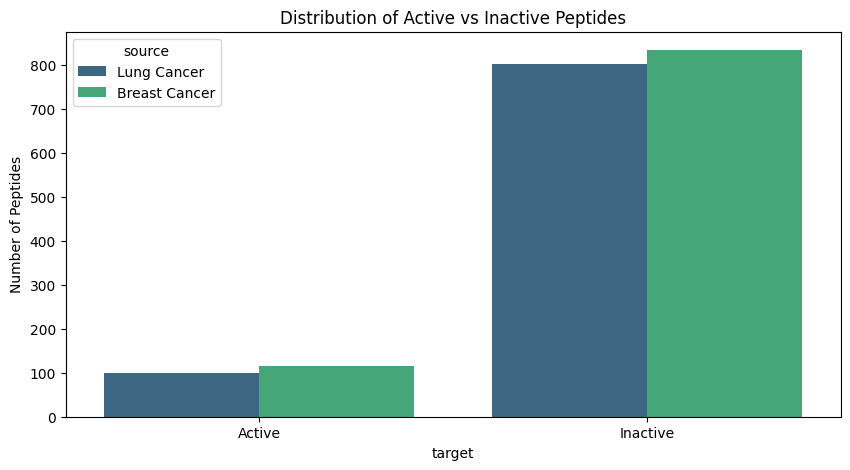

In [ ]:
# Plot Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_all, x='target', hue='source', palette='viridis')
plt.title('Distribution of Active vs Inactive Peptides')
plt.ylabel('Number of Peptides')
plt.show()

## **Sequence Length Distribution**

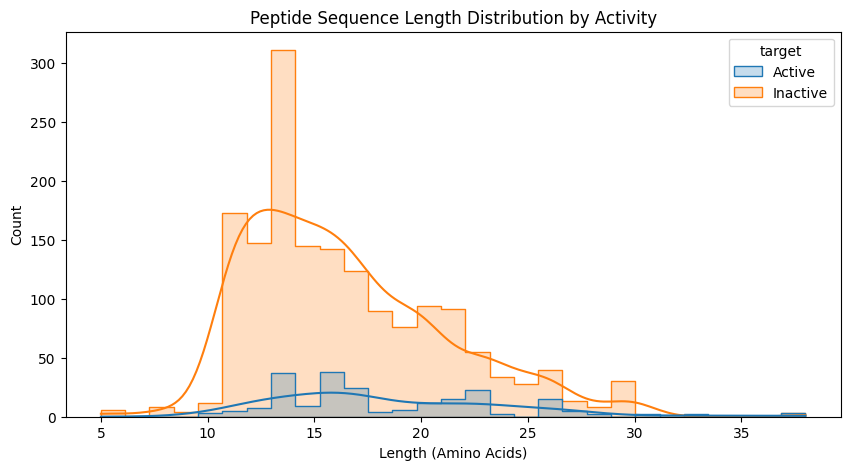

In [ ]:
# Plot Sequence Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all, x='length', hue='target', kde=True, element="step")
plt.title('Peptide Sequence Length Distribution by Activity')
plt.xlabel('Length (Amino Acids)')
plt.show()

## **Visualizing Sequence Length "Outliers"**

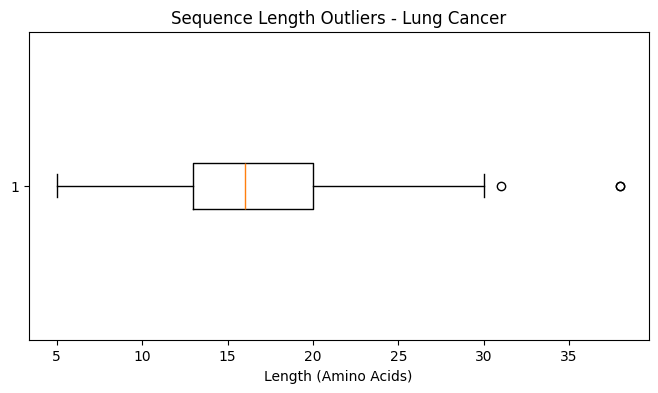

Sequences shorter than 4 residues: 0


In [ ]:
import matplotlib.pyplot as plt

def plot_length_outliers(df, title):
    lengths = df['sequence'].str.len()

    plt.figure(figsize=(8, 4))
    plt.boxplot(lengths, vert=False)
    plt.title(f'Sequence Length Outliers - {title}')
    plt.xlabel('Length (Amino Acids)')
    plt.show()

    # Statistical check for "missing" context (too short to be a peptide)
    too_short = df[df['sequence'].str.len() < 4]
    print(f"Sequences shorter than 4 residues: {len(too_short)}")

plot_length_outliers(df_lung, "Lung Cancer")

## **Amino Acid Composition Analysis**

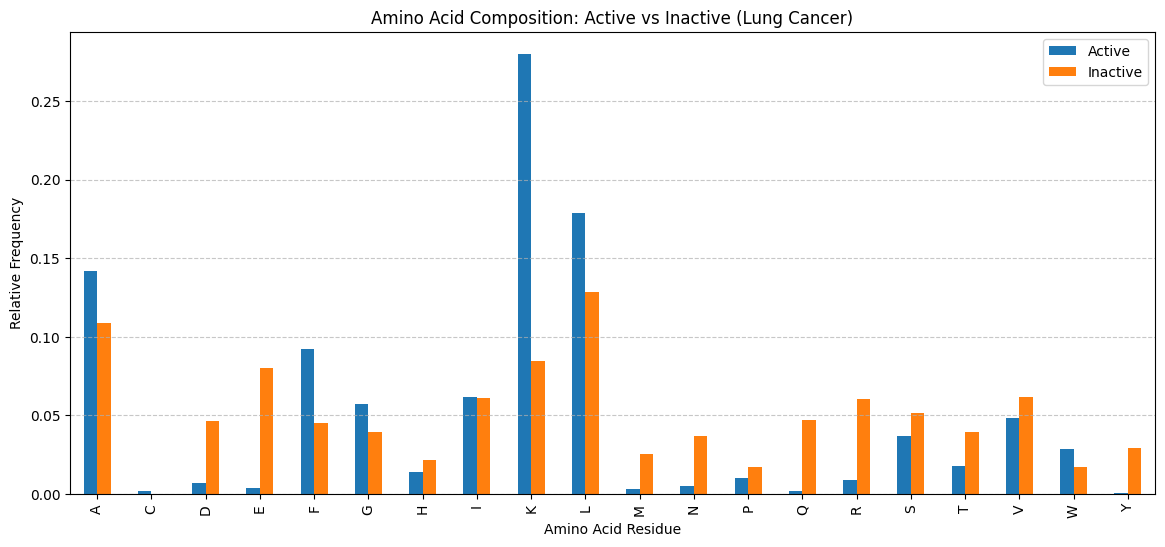

In [ ]:
def get_aa_composition(sequences):
    all_aas = "".join(sequences)
    counts = Counter(all_aas)
    total = sum(counts.values())
    return {aa: count/total for aa, count in sorted(counts.items())}

# Compare AA composition for Lung Cancer dataset
lung_active_aa = get_aa_composition(df_lung_proc[df_lung_proc['target'] == 'Active']['sequence'])
lung_inactive_aa = get_aa_composition(df_lung_proc[df_lung_proc['target'] == 'Inactive']['sequence'])

aa_comparison_df = pd.DataFrame([lung_active_aa, lung_inactive_aa], index=['Active', 'Inactive']).T

aa_comparison_df.plot(kind='bar', figsize=(14, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Amino Acid Composition: Active vs Inactive (Lung Cancer)')
plt.ylabel('Relative Frequency')
plt.xlabel('Amino Acid Residue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Dataset Overlap Check**

In [ ]:
lung_seqs = set(df_lung['sequence'])
breast_seqs = set(df_breast['sequence'])
overlap = lung_seqs.intersection(breast_seqs)

print(f"Total Unique Sequences (Combined): {len(lung_seqs.union(breast_seqs))}")
print(f"Overlapping Sequences between Lung and Breast: {len(overlap)}")

Total Unique Sequences (Combined): 971
Overlapping Sequences between Lung and Breast: 879


## **Checking Duplicate Rows**

In [ ]:
# Returns the total number of duplicate rows
duplicate_count = df_all.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Extraction: Amino Acid Composition (AAC)
def get_aac(seq):
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    return [seq.count(aa) / len(seq) for aa in amino_acids]

# Apply extraction
X = np.array([get_aac(s) for s in df_all['sequence']])
y = LabelEncoder().fit_transform(df_all['target']) # Active=0, Inactive=1 (check order)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training**

## **Training & Evaluating Models**


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.87      0.63      0.73        41
           1       0.96      0.99      0.97       329

    accuracy                           0.95       370
   macro avg       0.91      0.81      0.85       370
weighted avg       0.95      0.95      0.95       370



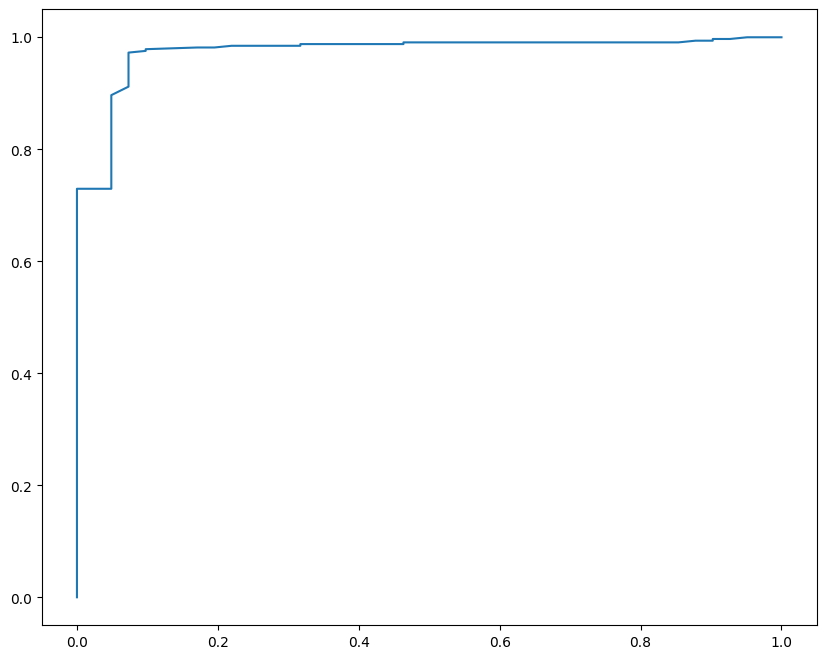

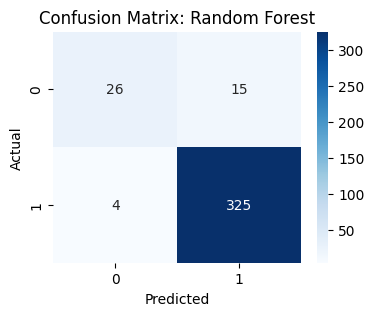


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.40      0.05      0.09        41
           1       0.89      0.99      0.94       329

    accuracy                           0.89       370
   macro avg       0.65      0.52      0.51       370
weighted avg       0.84      0.89      0.85       370



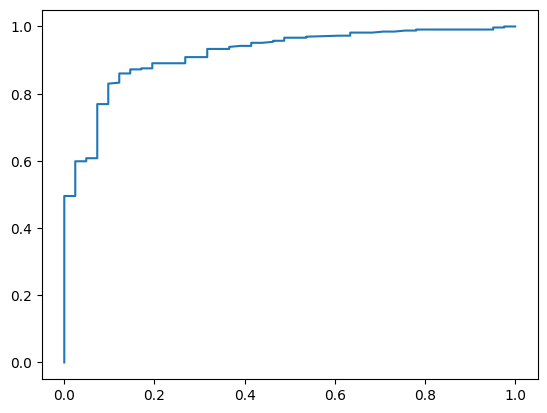

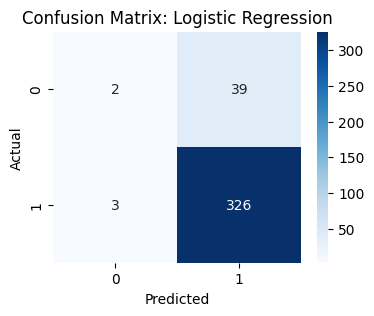


==================== SVM ====================
              precision    recall  f1-score   support

           0       0.70      0.34      0.46        41
           1       0.92      0.98      0.95       329

    accuracy                           0.91       370
   macro avg       0.81      0.66      0.71       370
weighted avg       0.90      0.91      0.90       370



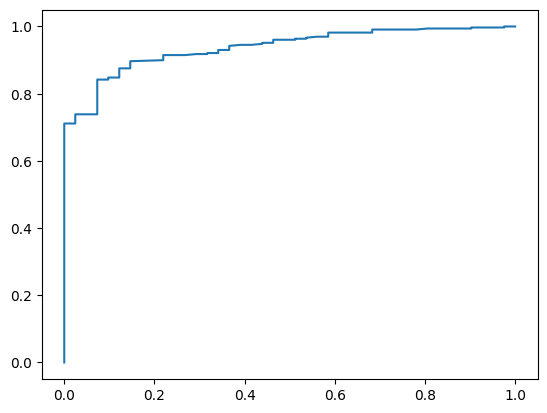

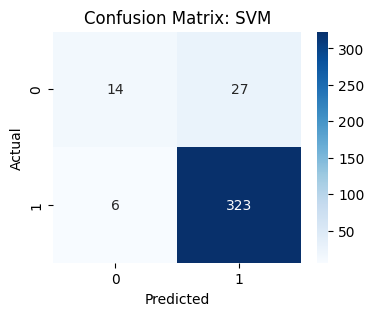

/tmp/ipython-input-3633942170.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


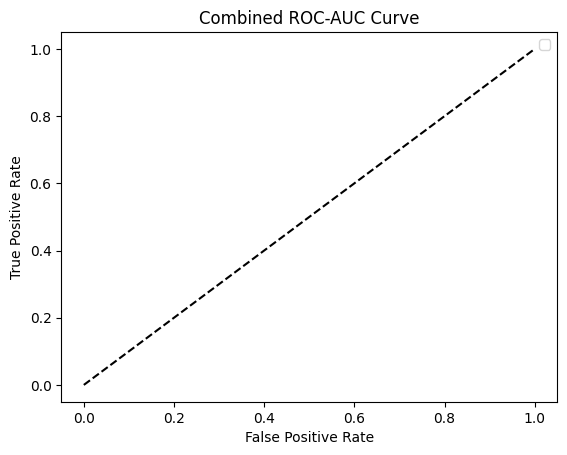

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Timing Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Timing Test
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_probs = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probs),
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }
    results.append(metrics)

    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.2f})")

    # Print Classification Report
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plotting
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Finalizing ROC Plot
plt.figure(1) # Go back to ROC figure
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC-AUC Curve')
plt.legend()
plt.show()

## **Summarized Evaluation Metrics**

In [ ]:
summary_df = pd.DataFrame(results)
print("\n### Final Model Comparison ###")
print(summary_df.to_string(index=False))


### Final Model Comparison ###
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Train Time (s)  Test Time (s)
      Random Forest  0.948649   0.955882 0.987842  0.971599 0.974275        0.539539       0.018872
Logistic Regression  0.886486   0.893151 0.990881  0.939481 0.918749        0.080661       0.004666
                SVM  0.910811   0.922857 0.981763  0.951399 0.937134        0.272600       0.034124


# **Hyperparameter Optimization with Optuna (Bayesian Optimization)**

## **Installing Optuna**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.1 MB/s eta 0:00:00


## **Finding Best Parameters & Evaluating**

[I 2026-02-09 04:02:15,227] A new study created in memory with name: no-name-4232b244-05d5-4e91-8d20-12c301778656


Optimizing Random Forest...


[I 2026-02-09 04:02:23,366] Trial 0 finished with value: 0.9652402298103168 and parameters: {'n_estimators': 189, 'max_depth': 29}. Best is trial 0 with value: 0.9652402298103168.
[I 2026-02-09 04:02:25,666] Trial 1 finished with value: 0.9577779879961269 and parameters: {'n_estimators': 214, 'max_depth': 5}. Best is trial 0 with value: 0.9652402298103168.
[I 2026-02-09 04:02:26,158] Trial 2 finished with value: 0.9644707070603191 and parameters: {'n_estimators': 54, 'max_depth': 8}. Best is trial 0 with value: 0.9652402298103168.
[I 2026-02-09 04:02:27,941] Trial 3 finished with value: 0.9488136569201738 and parameters: {'n_estimators': 184, 'max_depth': 4}. Best is trial 0 with value: 0.9652402298103168.
[I 2026-02-09 04:02:30,449] Trial 4 finished with value: 0.9645472171873347 and parameters: {'n_estimators': 271, 'max_depth': 31}. Best is trial 0 with value: 0.9652402298103168.
[I 2026-02-09 04:02:32,256] Trial 5 finished with value: 0.9645472171873347 and parameters: {'n_estimato

Best Params for Random Forest: {'n_estimators': 189, 'max_depth': 29}
Optimizing Logistic Regression...


[I 2026-02-09 04:02:44,455] Trial 6 finished with value: 0.9319731141237374 and parameters: {'C': 0.0010466995932797267}. Best is trial 1 with value: 0.9493928219193638.
[I 2026-02-09 04:02:44,494] Trial 7 finished with value: 0.9497577963987417 and parameters: {'C': 3.3464804736958245}. Best is trial 7 with value: 0.9497577963987417.
[I 2026-02-09 04:02:44,550] Trial 8 finished with value: 0.9390975489794476 and parameters: {'C': 0.019740855127588403}. Best is trial 7 with value: 0.9497577963987417.
[I 2026-02-09 04:02:44,606] Trial 9 finished with value: 0.9486256184364534 and parameters: {'C': 0.7761252264596006}. Best is trial 7 with value: 0.9497577963987417.
[I 2026-02-09 04:02:44,665] Trial 10 finished with value: 0.9486006031849348 and parameters: {'C': 7.885664530318182}. Best is trial 7 with value: 0.9497577963987417.
[I 2026-02-09 04:02:44,732] Trial 11 finished with value: 0.9486256184364534 and parameters: {'C': 0.7540179618220978}. Best is trial 7 with value: 0.9497577963

Best Params for Logistic Regression: {'C': 3.3464804736958245}
Optimizing SVM...


[I 2026-02-09 04:02:45,304] Trial 0 finished with value: 0.9375448028673835 and parameters: {'C': 0.03399169687969743, 'gamma': 0.006635080799839337}. Best is trial 0 with value: 0.9375448028673835.
[I 2026-02-09 04:02:45,896] Trial 1 finished with value: 0.9623968012439414 and parameters: {'C': 9.304967262289013, 'gamma': 0.12520007073917253}. Best is trial 1 with value: 0.9623968012439414.
[I 2026-02-09 04:02:46,288] Trial 2 finished with value: 0.9392304457625311 and parameters: {'C': 1.9374456921288137, 'gamma': 0.0019747672076001243}. Best is trial 1 with value: 0.9623968012439414.
[I 2026-02-09 04:02:46,729] Trial 3 finished with value: 0.9581834534623024 and parameters: {'C': 26.4330945910612, 'gamma': 0.005746462736311487}. Best is trial 1 with value: 0.9623968012439414.
[I 2026-02-09 04:02:47,042] Trial 4 finished with value: 0.9375448028673835 and parameters: {'C': 0.013671845055221886, 'gamma': 0.00010918507518825174}. Best is trial 1 with value: 0.9623968012439414.
[I 2026-

Best Params for SVM: {'C': 9.304967262289013, 'gamma': 0.12520007073917253}

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.63      0.73        41
           1       0.96      0.99      0.97       329

    accuracy                           0.95       370
   macro avg       0.91      0.81      0.85       370
weighted avg       0.95      0.95      0.95       370



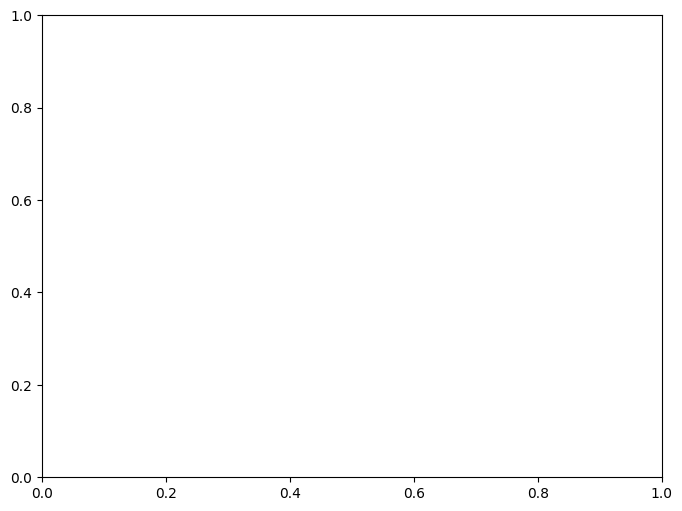

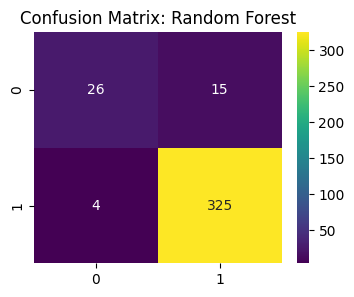


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.37      0.48        41
           1       0.93      0.98      0.95       329

    accuracy                           0.91       370
   macro avg       0.82      0.67      0.72       370
weighted avg       0.90      0.91      0.90       370



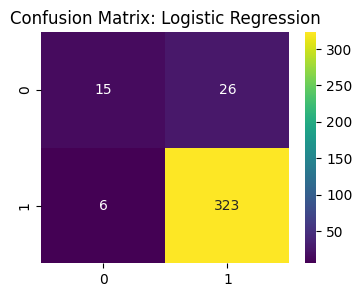


--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.68      0.75        41
           1       0.96      0.98      0.97       329

    accuracy                           0.95       370
   macro avg       0.89      0.83      0.86       370
weighted avg       0.95      0.95      0.95       370



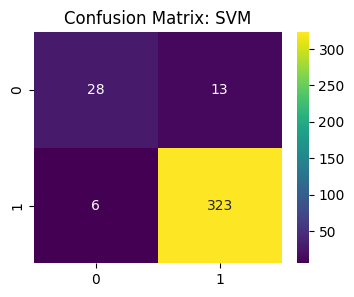


### SUMMARIZED EVALUATION METRICS ###
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  TrainTime(s)  TestTime(s)
      Random Forest  0.948649   0.955882 0.987842  0.971599 0.975313        0.5373       0.0198
Logistic Regression  0.913514   0.925501 0.981763  0.952802 0.940470        0.0121       0.0005
                SVM  0.948649   0.961310 0.981763  0.971429 0.920824        0.1717       0.0075


In [ ]:
import time
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# --- 1. Scaling (Essential for LR and SVM) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Hyperparameter Tuning with Optuna ---
def tune_models(X, y):
    best_models = {}

    # Random Forest Tuning
    def rf_obj(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 32),
            'random_state': 42
        }
        return cross_val_score(RandomForestClassifier(**params), X, y, n_jobs=-1, cv=3, scoring='f1').mean()

    # Logistic Regression Tuning
    def lr_obj(trial):
        params = {
            'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
            'solver': 'liblinear',
            'random_state': 42
        }
        return cross_val_score(LogisticRegression(**params), X, y, n_jobs=-1, cv=3, scoring='f1').mean()

    # SVM Tuning
    def svm_obj(trial):
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True),
            'probability': True,
            'random_state': 42
        }
        return cross_val_score(SVC(**params), X, y, n_jobs=-1, cv=3, scoring='f1').mean()

    objectives = [("Random Forest", rf_obj), ("Logistic Regression", lr_obj), ("SVM", svm_obj)]

    for name, obj in objectives:
        print(f"Optimizing {name}...")
        study = optuna.create_study(direction="maximize")
        study.optimize(obj, n_trials=15)
        print(f"Best Params for {name}: {study.best_params}")

        if name == "Random Forest":
            best_models[name] = RandomForestClassifier(**study.best_params, random_state=42)
        elif name == "Logistic Regression":
            best_models[name] = LogisticRegression(**study.best_params, solver='liblinear', random_state=42)
        else:
            best_models[name] = SVC(**study.best_params, probability=True, random_state=42)

    return best_models

# Run Tuning
optimized_models = tune_models(X_train_scaled, y_train)

# --- 3. Final Evaluation & Plotting ---
results = []
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for name, model in optimized_models.items():
    # Performance Monitoring
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - t1
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Store Metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probs),
        "TrainTime(s)": round(train_time, 4),
        "TestTime(s)": round(test_time, 4)
    }
    results.append(metrics)

    # Classification Report & Confusion Matrix
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    # ROC Plotting
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.2f})")

# Finalize ROC Plot
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_title("Combined ROC-AUC Curve")
ax_roc.legend()
plt.show()

# --- 4. Summarized Evaluation Metrics ---
summary_df = pd.DataFrame(results)
print("\n### SUMMARIZED EVALUATION METRICS ###")
print(summary_df.to_string(index=False))

# **Monte-Carlo Cross Validation**

Starting Monte-Carlo Cross-Validation (10 Iterations)...

### MONTE-CARLO CROSS-VALIDATION SUMMARY (10 ITERATIONS) ###
              Model  Mean F1  F1 Std Dev  Mean ROC-AUC  Mean Accuracy  Mean Precision  Mean Recall
      Random Forest 0.967145    0.006757      0.967828       0.941892        0.958398     0.976257
Logistic Regression 0.948926    0.012287      0.949488       0.909459        0.938372     0.960208
                SVM 0.967491    0.010794      0.928989       0.942568        0.959576     0.975888


/tmp/ipython-input-2915926267.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores, labels=labels)


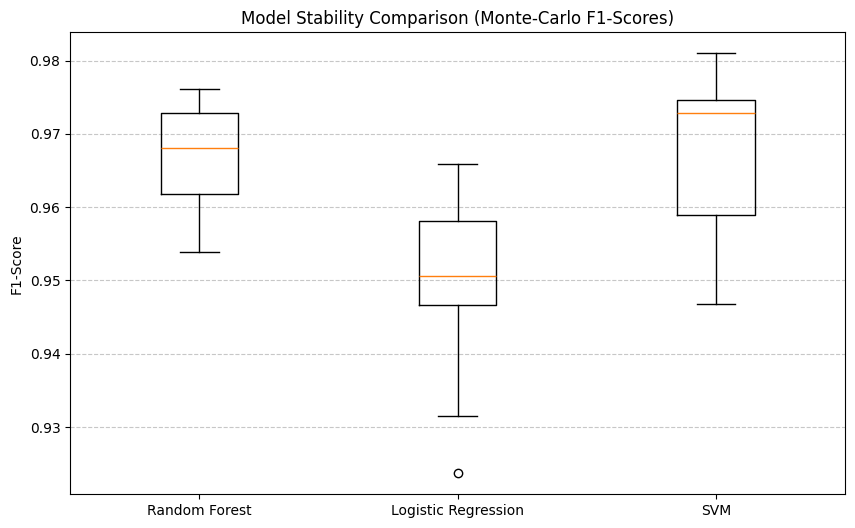

In [ ]:
from sklearn.model_selection import ShuffleSplit, cross_validate

# --- 1. Define Monte-Carlo Parameters ---
# n_splits=10 means we will shuffle and split the data 10 times
mc_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

mc_results = []

print(f"Starting Monte-Carlo Cross-Validation (10 Iterations)...\n")

# --- 2. Run MC-CV for each Optimized Model ---
for name, model in optimized_models.items():
    # We use cross_validate to get multiple metrics at once
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    cv_results = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=mc_cv,
        scoring=scoring,
        n_jobs=-1
    )

    # Calculate Mean and Standard Deviation for stability analysis
    mc_results.append({
        "Model": name,
        "Mean F1": np.mean(cv_results['test_f1']),
        "F1 Std Dev": np.std(cv_results['test_f1']),
        "Mean ROC-AUC": np.mean(cv_results['test_roc_auc']),
        "Mean Accuracy": np.mean(cv_results['test_accuracy']),
        "Mean Precision": np.mean(cv_results['test_precision']),
        "Mean Recall": np.mean(cv_results['test_recall'])
    })

# --- 3. Summarized MC-CV Metrics ---
mc_summary_df = pd.DataFrame(mc_results)
print("### MONTE-CARLO CROSS-VALIDATION SUMMARY (10 ITERATIONS) ###")
print(mc_summary_df.to_string(index=False))

# --- 4. Visualization of Model Stability (F1-Score Distribution) ---
plt.figure(figsize=(10, 6))
# Collecting all individual scores for the boxplot
all_scores = []
labels = []
for name, model in optimized_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=mc_cv, scoring='f1')
    all_scores.append(scores)
    labels.append(name)

plt.boxplot(all_scores, labels=labels)
plt.title("Model Stability Comparison (Monte-Carlo F1-Scores)")
plt.ylabel("F1-Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Model Interpretability**

## **Spearman Correlation & Feature Importance**

--- Length Analysis ---
Spearman Correlation (Length vs. Target): -0.1248
P-value: 7.3079e-08


/tmp/ipython-input-2116820810.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='length', data=df_all, palette='Set2')


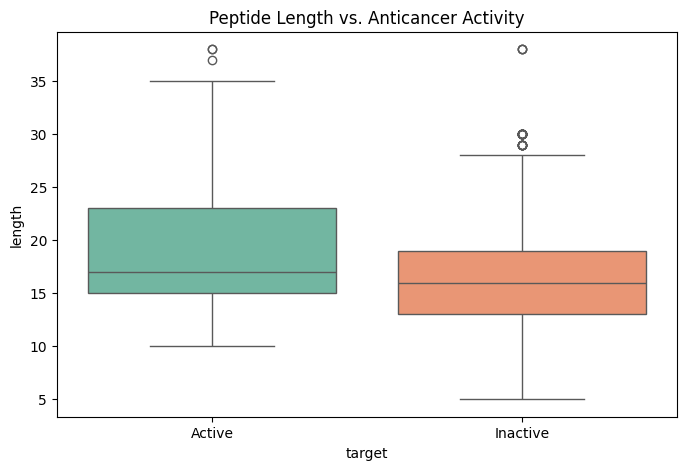


--- Specific Amino Acid Analysis (Cysteine) ---
Mean Cysteine % (Active): 0.24%
Mean Cysteine % (Inactive): 0.00%
Mann-Whitney U P-value: 1.3489e-11


/tmp/ipython-input-2116820810.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='C_content', data=df_all, inner="quartile", palette='Pastel1')


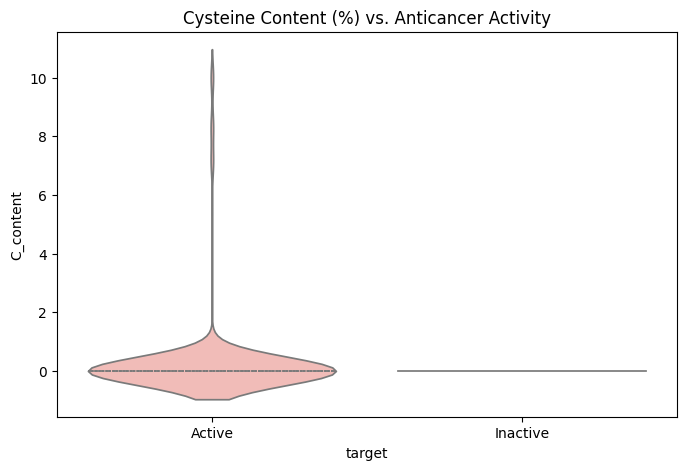

/tmp/ipython-input-2116820810.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='AA', data=feature_info, palette='viridis')


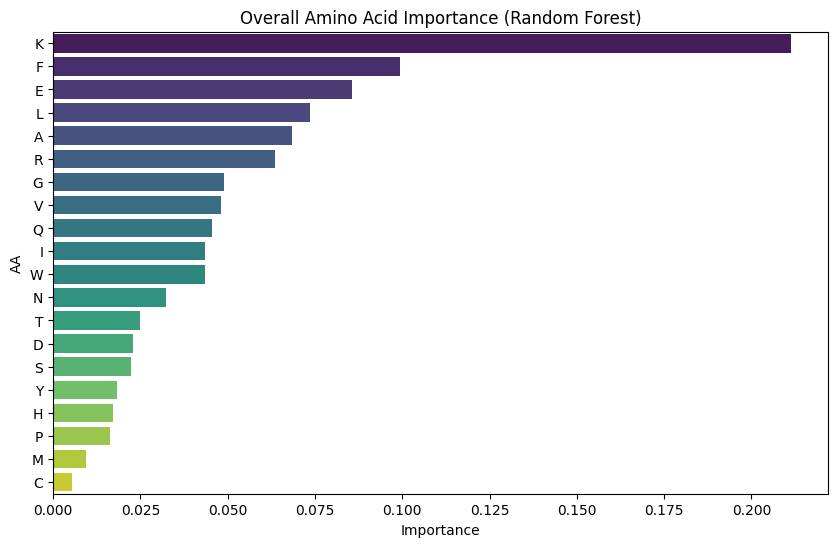

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

# --- 1. Correlation: Sequence Length vs. Activity ---
# We use Spearman because activity is categorical (0/1)
corr, p_value = spearmanr(df_all['length'], y)

print(f"--- Length Analysis ---")
print(f"Spearman Correlation (Length vs. Target): {corr:.4f}")
print(f"P-value: {p_value:.4e}")

# Visualization: Length Distribution
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='length', data=df_all, palette='Set2')
plt.title('Peptide Length vs. Anticancer Activity')
plt.show()

# --- 2. Amino Acid Importance: The "Cysteine" Factor ---
# Calculate Cysteine (C) content for each sequence
df_all['C_content'] = df_all['sequence'].apply(lambda x: (x.count('C') / len(x)) * 100)

# Statistical Test (Mann-Whitney U) to compare C content in Active vs Inactive
active_c = df_all[df_all['target'] == 'Active']['C_content']
inactive_c = df_all[df_all['target'] == 'Inactive']['C_content']
stat, p_cys = mannwhitneyu(active_c, inactive_c)

print(f"\n--- Specific Amino Acid Analysis (Cysteine) ---")
print(f"Mean Cysteine % (Active): {active_c.mean():.2f}%")
print(f"Mean Cysteine % (Inactive): {inactive_c.mean():.2f}%")
print(f"Mann-Whitney U P-value: {p_cys:.4e}")

# Visualization: Cysteine Content
plt.figure(figsize=(8, 5))
sns.violinplot(x='target', y='C_content', data=df_all, inner="quartile", palette='Pastel1')
plt.title('Cysteine Content (%) vs. Anticancer Activity')
plt.show()

# --- 3. Feature Importance from the Optimized Random Forest ---
# This tells us which of ALL 20 amino acids the model found most important
rf_model = optimized_models['Random Forest']
importances = rf_model.feature_importances_
aa_labels = list('ACDEFGHIKLMNPQRSTVWY')

feature_info = pd.DataFrame({'AA': aa_labels, 'Importance': importances})
feature_info = feature_info.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='AA', data=feature_info, palette='viridis')
plt.title('Overall Amino Acid Importance (Random Forest)')
plt.show()

## **Shap Based Analysis**

<Figure size 1000x800 with 0 Axes>

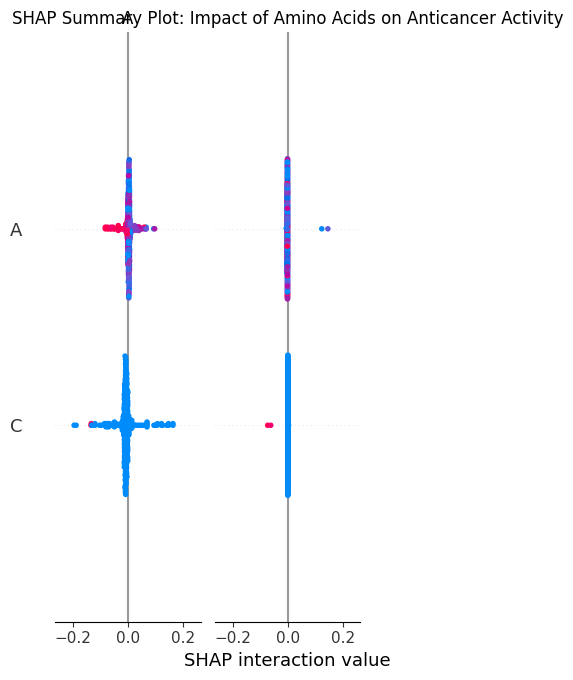

In [ ]:
import shap

# 1. Initialize the SHAP Explainer
# We use TreeExplainer for Random Forest as it is high-performance
rf_model = optimized_models['Random Forest']
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for the test set
# For classification, we take index [1] to explain the "Active" class
shap_values = explainer.shap_values(X_test_scaled)

# If the output is a list (standard for multiclass/binary in some versions),
# we select the values for the 'Active' class (usually index 1)
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# 3. Create the SHAP Summary Plot
aa_labels = list('ACDEFGHIKLMNPQRSTVWY') # Amino Acid labels

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=aa_labels, show=False)
plt.title("SHAP Summary Plot: Impact of Amino Acids on Anticancer Activity")
plt.show()